<a href="https://colab.research.google.com/github/raphasandes/Auditoria-Vendas-e-Lucratividade/blob/main/Desafio_Organizando_e_analisando_dados_de_um_Airbnb.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Desafio: Organizando e analisando dados de um Airbnb**

# Etapa 01)  Carregando os dados

In [1]:
#Importando bibliotecas necessárias
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
# Carregando as duas planilhas
df_listings = pd.read_csv('listings_cleaned.csv')
df_reviews = pd.read_csv('reviews.csv')

In [16]:
#Juntando os datasets com o código "merge"/inner join
df = pd.merge(df_listings, df_reviews, on='id', how='inner')

In [17]:
#Verificando a junção das duas tabelas
df.head(10)

,id,neighbourhood_cleansed,room_type,accommodates,bathrooms,bedrooms,beds,price,number_of_reviews,review_scores_rating
0,272335,Copacabana,Entire home/apt,4,1.0,1.0,1.0,723.0,367,4.920000
1,272631,Copacabana,Private room,2,1.0,1.0,2.0,1146.0,32,5.000000
2,273261,Leblon,Entire home/apt,6,3.5,3.0,3.0,6742.0,0,4.812309
3,273363,Santa Teresa,Private room,1,1.0,1.0,1.0,61.0,5,5.000000
4,273463,Lagoa,Entire home/apt,6,2.0,2.0,6.0,1411.0,654,4.830000
5,273496,Leblon,Entire home/apt,6,2.5,2.0,5.0,703.0,60,4.800000
6,273753,Santa Teresa,Private room,1,1.0,1.0,1.0,59.0,4,4.500000
7,274116,Santa Teresa,Entire home/apt,3,1.0,1.0,2.0,225.0,48,4.920000
8,278679,Copacabana,Entire home/apt,2,1.0,0.0,1.0,759.0,59,4.850000
9,17878,Copacabana,Entire home/apt,5,1.0,2.0,2.0,1471.0,327,4.700000


# Etapa 02)  Limpeza e Tratamento de Dados

In [19]:
# Verificando se os tipos de dados fazem sentido
# Preço deve ser float/int, nomes devem ser object/string
print(df.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 32695 entries, 0 to 32694
Data columns (total 10 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   id                      32695 non-null  int64  
 1   neighbourhood_cleansed  32695 non-null  object 
 2   room_type               32695 non-null  object 
 3   accommodates            32695 non-null  int64  
 4   bathrooms               32695 non-null  float64
 5   bedrooms                32695 non-null  float64
 6   beds                    32695 non-null  float64
 7   price                   32695 non-null  float64
 8   number_of_reviews       32695 non-null  int64  
 9   review_scores_rating    32695 non-null  float64
dtypes: float64(5), int64(3), object(2)
memory usage: 2.5+ MB
None


In [18]:
# Verificando valores ausentes
df.isnull().sum()

,0
id,0
neighbourhood_cleansed,0
room_type,0
accommodates,0
bathrooms,0
bedrooms,0
beds,0
price,0
number_of_reviews,0
review_scores_rating,0


In [21]:
# Preenchendo ddados de banheiros, quartos e camas com a mediana
df['bathrooms'] = df['bathrooms'].fillna(df['bathrooms'].median())
df['bedrooms'] = df['bedrooms'].fillna(df['bedrooms'].median())
df['beds'] = df['beds'].fillna(df['beds'].median())

In [22]:
# Removendo notas nulas, caso hajam
df.dropna(subset=['review_scores_rating'], inplace=True)

# Etapa 03) Tratando e Visualizando Outliers

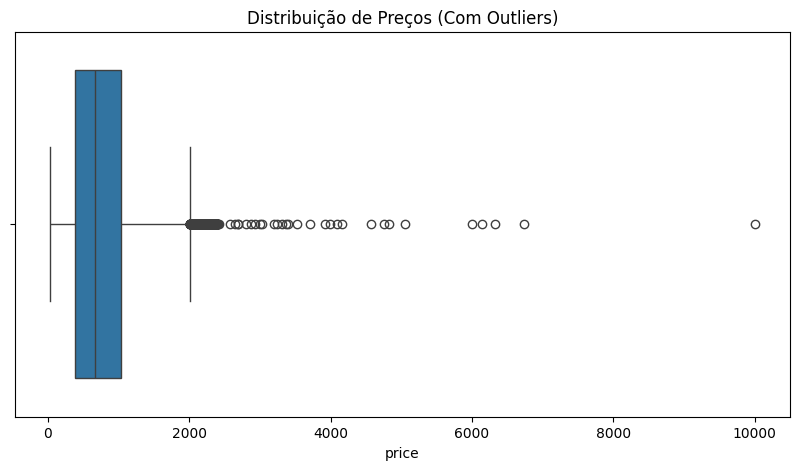

In [23]:
# Montando boxplot para visualizar outliers
plt.figure(figsize=(10, 5))
sns.boxplot(x=df['price'])
plt.title('Distribuição de Preços (Com Outliers)')
plt.show()

In [25]:
# Cálculo de quartis
Q1 = df['price'].quantile(0.25)
Q3 = df['price'].quantile(0.75)
IQR = Q3 - Q1

In [26]:
# Definição dos limites (IQR)
limite_inferior = Q1 - 1.5 * IQR
limite_superior = Q3 + 1.5 * IQR

In [28]:
# Definindo novo dataframe a partir dos limites estipulados
df_filtrado = df[(df['price'] >= limite_inferior) & (df['price'] <= limite_superior)]

<Axes: xlabel='price'>

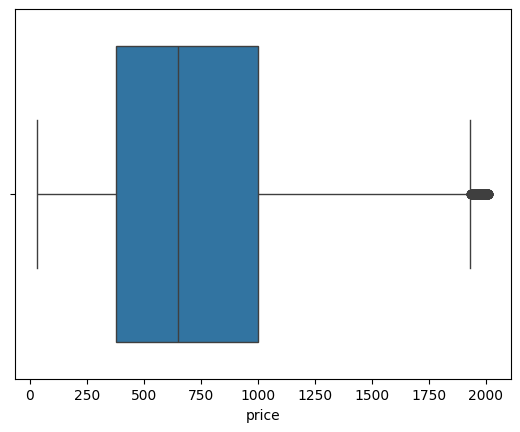

In [29]:
# Gerando o novo boxplot, a partir do dataframe filtrado
import seaborn as sns
sns.boxplot(x=df_filtrado['price'])

# Etapa 04: Transformando Dados Categóricos


In [31]:
# Criando códigos para o tipo de quarto
df_filtrado ['room_type_code'] = df_filtrado ['room_type'].astype('category').cat.codes

/tmp/ipython-input-197782690.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_filtrado ['room_type_code'] = df_filtrado ['room_type'].astype('category').cat.codes


In [32]:
df_filtrado.head()

,id,neighbourhood_cleansed,room_type,accommodates,bathrooms,bedrooms,beds,price,number_of_reviews,review_scores_rating,room_type_code
0,272335,Copacabana,Entire home/apt,4,1.0,1.0,1.0,723.0,367,4.92,0
1,272631,Copacabana,Private room,2,1.0,1.0,2.0,1146.0,32,5.00,2
3,273363,Santa Teresa,Private room,1,1.0,1.0,1.0,61.0,5,5.00,2
4,273463,Lagoa,Entire home/apt,6,2.0,2.0,6.0,1411.0,654,4.83,0
5,273496,Leblon,Entire home/apt,6,2.5,2.0,5.0,703.0,60,4.80,0


In [33]:
print(df_filtrado['room_type'].value_counts())

room_type
Entire home/apt    25125
Private room        6404
Shared room          227
Hotel room            16
Name: count, dtype: int64


In [35]:
mapeamento_quarto = dict(enumerate(df_filtrado['room_type'].astype('category').cat.categories))
print("Mapeamento de Categorias:", mapeamento_quarto)

Mapeamento de Categorias: {0: 'Entire home/apt', 1: 'Hotel room', 2: 'Private room', 3: 'Shared room'}


In [37]:
# Removendo colunas que não usaremos mais (opcional)
df_final = df_filtrado.drop(columns=['id'])

In [39]:
print(df_filtrado.info())
print(df_filtrado.describe())

<class 'pandas.core.frame.DataFrame'>
Index: 31772 entries, 0 to 32694
Data columns (total 11 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   id                      31772 non-null  int64  
 1   neighbourhood_cleansed  31772 non-null  object 
 2   room_type               31772 non-null  object 
 3   accommodates            31772 non-null  int64  
 4   bathrooms               31772 non-null  float64
 5   bedrooms                31772 non-null  float64
 6   beds                    31772 non-null  float64
 7   price                   31772 non-null  float64
 8   number_of_reviews       31772 non-null  int64  
 9   review_scores_rating    31772 non-null  float64
 10  room_type_code          31772 non-null  int8   
dtypes: float64(5), int64(3), int8(1), object(2)
memory usage: 2.7+ MB
None
                 id  accommodates   bathrooms      bedrooms          beds  \
count  3.177200e+04  31772.000000  31772.0000  31772.0